In [ ]:
import cv2
import numpy as np

from PIL import Image
from IPython.display import display

import skimage as ski


def show(img_rgb, scale_factor=0.25):
    # if greyscale, convert to RGB
    if len(img_rgb.shape) == 2:
        img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_GRAY2RGB)
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    scaled_img = cv2.resize(img_rgb, (img_rgb.shape[1] // int(1/scale_factor), img_rgb.shape[0] // int(1/scale_factor)))
    display(Image.fromarray(scaled_img))
    return

video_source = r"uploads\IMG_1759.MOV"  # Change this to your video file path or camera index

cap = cv2.VideoCapture(video_source)
_ret, cap_1 = cap.read()  # Read the first frame to check if the video is valid

# get frame number 32
cap.set(cv2.CAP_PROP_POS_FRAMES, 32)
_ret, cap_32 = cap.read()
# cap_32 = cap_32[cap_32.shape[0]//4:cap_32.shape[0], :]  # crop to bottom 3/4ths
# cap_32 = cv2.imread(r"uploads\frames\frame_0011.png")  # for testing purposes, use a saved frame instead of the video frame

show(cap_1)
show(cap_32)
print(f"Resolution: {cap_1.shape}, FPS: {cap.get(cv2.CAP_PROP_FPS)}, Total Frames: {cap.get(cv2.CAP_PROP_FRAME_COUNT)}, duration: {cap.get(cv2.CAP_PROP_FRAME_COUNT) / cap.get(cv2.CAP_PROP_FPS)} seconds")

Starting the idolating sclera stuff

In [ ]:
import numpy as np

# cap_32_blur = cv2.blur(cap_32, (51, 51))
aspect_ratio = cap_32.shape[1] / cap_32.shape[0]
new_w = 500
if new_w > cap_32.shape[1]:
    new_w = int(cap_32.shape[1] * .25)
new_h = int(new_w / aspect_ratio)

cap_32_lowRes = cv2.resize(cap_32, (new_w, new_h), interpolation=cv2.INTER_AREA)
# cap_32_lowRes = cap_32_lowRes[new_h//4:new_h, :]  # crop to bottom 3/4ths
show(cap_32_lowRes)

In [ ]:
cap_32_hsv = cv2.cvtColor(cap_32_lowRes, cv2.COLOR_BGR2HSV)

thresh_hsv = cv2.inRange(cap_32_hsv, (0, 1, 180), (180, 35, 255))
opened_hsv = cv2.morphologyEx(thresh_hsv, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))
close_hsv = cv2.morphologyEx(opened_hsv, cv2.MORPH_CLOSE, np.ones((11,11), np.uint8))
larg_Contour, _ = cv2.findContours(close_hsv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(larg_Contour, key=cv2.contourArea) if larg_Contour else None
peri = cv2.arcLength(largest_contour, True)
simplified_contour = cv2.approxPolyDP(largest_contour, epsilon=0.015 * peri, closed=True)
#  get the corresponding mask of the largest contour
mask = np.zeros_like(close_hsv)
mask = cv2.drawContours(mask, [simplified_contour], -1, 255, thickness=cv2.FILLED)
    
show(thresh_hsv)
show(opened_hsv)
show(close_hsv)
show(mask)


In [ ]:

# Take the contour coords and multiply by a transformation matrix to get the corresponding coords in the original image, then draw the contour on the original image
M = np.array([[cap_32.shape[1] / new_w, 0, 0],
              [0, cap_32.shape[0] / new_h, 25],
              [0, 0, 1]])

# make the contour coords homogeneous
# take out one of the wrappers for the contour coords
homogeneous_coords = np.hstack([largest_contour.reshape(-1, 2), np.ones((largest_contour.shape[0], 1))])
print(f"homogeneous coords shape: {homogeneous_coords.shape} and values: {homogeneous_coords[:5]}")
transformed_coords = (M @ homogeneous_coords.T).T[:, :2].astype(int)

# draw the contour on the original image
contour_img = cap_32.copy()
contour_zero = np.zeros_like(contour_img)
mask = cv2.drawContours(contour_zero, [transformed_coords], -1, 255, thickness=cv2.FILLED)
contour_img = cap_32 * mask.astype(bool)
print(f"contour_img shape: {contour_img.shape}")

#debugging code to look for good pixels
nonzero_mask = np.any(contour_img != 0, axis=2)  # shape: (1080, 1280)
rows, cols = np.where(nonzero_mask)

print(f"contour_img pixel at ({rows[0:5]}, {cols[0:5]}): {contour_img[rows[0:5], cols[0:5]]}")
# print(f"contour_img values: {np.unique(contour_img)}") # use numpy to show me a pixel with values
print(f"mask shape: {mask.shape} cap_32.shape: {cap_32.shape}")
show(contour_img)


show(mask)


OK so that was all the sclera stuff, this going to optimizing the stabilization

In [ ]:
#close the first video capture
# cap.close()
# cap.release()
def show(img_rgb, scale_factor=0.25):
    # if greyscale, convert to RGB
    if len(img_rgb.shape) == 2:
        img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_GRAY2RGB)
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    scaled_img = cv2.resize(img_rgb, (img_rgb.shape[1] // int(1/scale_factor), img_rgb.shape[0] // int(1/scale_factor)))
    display(Image.fromarray(scaled_img))
    return


import os
from CV_steps.sclera import sclera_pipeline
from PIL import Image


# cap = cv2.VideoCapture(video_source)
video_source = r"uploads\IMG_1759.MOV"  # Change this to your video file path or camera index

testing_out = os.path.join("output", "jupyter_test")
os.makedirs(testing_out, exist_ok=True)
print(f"Testing output directory: {testing_out}")

outlined_path = os.path.join(testing_out, "sclera_outline.mp4")
mask_path = os.path.join(testing_out, "sclera_mask.mp4")

# sclera_pipeline(str(video_source), outlined_path, mask_path, max_workers=8)

In [ ]:
from CV_steps.stabilize import stabilize_video


stabilize_video(mask_path, os.path.join(testing_out, f"sclera_mask_stabilized.mp4"))

# try a bunch of different smoothing radius values and see how it looks
# for radius in [10, 20, 30, 50, 75, 100]:
#     stabilize_video(mask_path, os.path.join(testing_out, f"sclera_mask_stabilized_{radius}.mp4"), smoothing_radius=radius)
#     print(f"Stabilized video with radius {radius} saved to {os.path.join(testing_out, f'sclera_mask_stabilized_{radius}.mp4')}")

# Also test stabilizing then isolating the sclear

# stab_path = os.path.join(testing_out, f"video_stabilized.mp4")
# stabilize_video(video_source, stab_path, smoothing_radius=50)

# sclera_pipeline(stab_path, os.path.join(testing_out, f"video_stabilized_sclera_outline.mp4"), os.path.join(testing_out, f"video_stabilized_sclera_mask.mp4"), max_workers=8)

In [ ]:
# Import numpy and OpenCV
import numpy as np
import cv2
 
# Read input video
cap = cv2.VideoCapture(mask_path)
 
# Get frame count
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
 
# Get width and height of video stream
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
 
# Define the codec for output video
fourcc = cv2.VideoWriter_fourcc(*'MJPG')


In [ ]:
# Read first frame
_, prev = cap.read()
 
# Convert frame to grayscale
prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)

# show features detected in the first frame
# make a mask of all the current data and then erode it shrink it
mask = cv2.threshold(prev_gray, 1, 255, cv2.THRESH_BINARY)[1]
# somehow shrink the mask

# kernel = np.ones((5,5), np.uint8)
# mask = cv2.erode(mask, kernel, iterations=5)

dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5) # calculate distance from edge for each pixel
mask = (dist > 50).astype(np.uint8) * 255  # keep only pixels >50px from any edge

show(mask)
features = cv2.goodFeaturesToTrack(prev_gray, maxCorners=200, qualityLevel=0.01, minDistance=30, blockSize=3, mask=mask)
features = np.intp(features)

featured_prev = cv2.cvtColor(prev_gray, cv2.COLOR_GRAY2BGR)
for feature in features:
    x, y = feature.ravel()
    cv2.circle(featured_prev, (x, y), 5, (0, 255, 0), -1)

show(featured_prev)



In [ ]:
import os
import numpy as np
import cv2
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
mask_path   = Path(r"C:\Users\dragon\Code\CatsEye-Python\output\results_20260502-014013\sclera_overlay.mp4")
testing_out = Path(r"C:\Users\dragon\Code\CatsEye-Python\output\testing_sclera")
testing_out.mkdir(parents=True, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
FEATURE_PARAMS = dict(maxCorners=200, qualityLevel=0.01, minDistance=30, blockSize=3)
LK_PARAMS      = dict(winSize=(21, 21), maxLevel=3,
                      criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))
EDGE_MARGIN    = 50   # px from any non-zero edge to exclude
REDETECT_EVERY = 30   # re-detect corners every N frames


# ── Helpers ───────────────────────────────────────────────────────────────────
def build_feature_mask(gray: np.ndarray, margin: int = EDGE_MARGIN) -> np.ndarray:
    """Return a mask keeping only pixels >margin px from the sclera boundary."""
    binary = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)[1]
    dist   = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    return (dist > margin).astype(np.uint8) * 255


def detect_features(gray: np.ndarray) -> np.ndarray:
    mask = build_feature_mask(gray)
    pts  = cv2.goodFeaturesToTrack(gray, mask=mask, **FEATURE_PARAMS)
    return pts.astype(np.float32) if pts is not None else np.empty((0, 1, 2), np.float32)


# ── Open video ────────────────────────────────────────────────────────────────
cap      = cv2.VideoCapture(str(mask_path))
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
w        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h        = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps      = cap.get(cv2.CAP_PROP_FPS)

out_path   = str(testing_out / "notebook_test.mp4")
out_writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
print(f"Writer ready → {out_path}  |  {w}×{h} @ {fps:.1f} fps")

# ── Bootstrap first frame ─────────────────────────────────────────────────────
ok, prev = cap.read()
if not ok:
    raise RuntimeError("Could not read first frame.")

prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)
prev_pts  = detect_features(prev_gray)

# ── Main loop ─────────────────────────────────────────────────────────────────
for frame_idx in range(1, n_frames):
    ok, img = cap.read()
    if not ok:
        print(f"Stream ended at frame {frame_idx}.")
        break

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Re-detect periodically or when we've lost too many points
    if frame_idx % REDETECT_EVERY == 0 or len(prev_pts) < 10:
        prev_pts = detect_features(prev_gray)

    if len(prev_pts) > 0:
        # Track prev_pts from prev_gray → gray
        curr_pts, status, _ = cv2.calcOpticalFlowPyrLK(prev_gray, gray, prev_pts, None, **LK_PARAMS)

        good_old = prev_pts[status == 1]
        good_new = curr_pts[status == 1]

        if len(good_old) >= 4:
            # matrix, _ = cv2.findHomography(good_old, good_new, cv2.RANSAC, 5.0)
            matrix, _ = cv2.estimateAffinePartial2D(good_old, good_new, method=cv2.RANSAC, ransacReprojThreshold=5.0)
            if matrix is not None:
                # stabilized = cv2.warpPerspective(img, matrix, (w, h))
                stabilized = cv2.warpAffine(img, matrix, (w, h))  # use warpAffine for affine matrix
                out_writer.write(stabilized)
            else:
                print(f"Frame {frame_idx}: homography failed — writing original.")
                out_writer.write(img)
        else:
            print(f"Frame {frame_idx}: only {len(good_old)} good points — writing original.")
            out_writer.write(img)

        prev_pts = good_new.reshape(-1, 1, 2)
    else:
        print(f"Frame {frame_idx}: no trackable features — writing original.")
        out_writer.write(img)

    prev_gray = gray

# ── Cleanup ───────────────────────────────────────────────────────────────────
cap.release()
out_writer.release()
print(f"Done. Stabilized video → {out_path}")

Original image shape: (3840, 2160, 3)


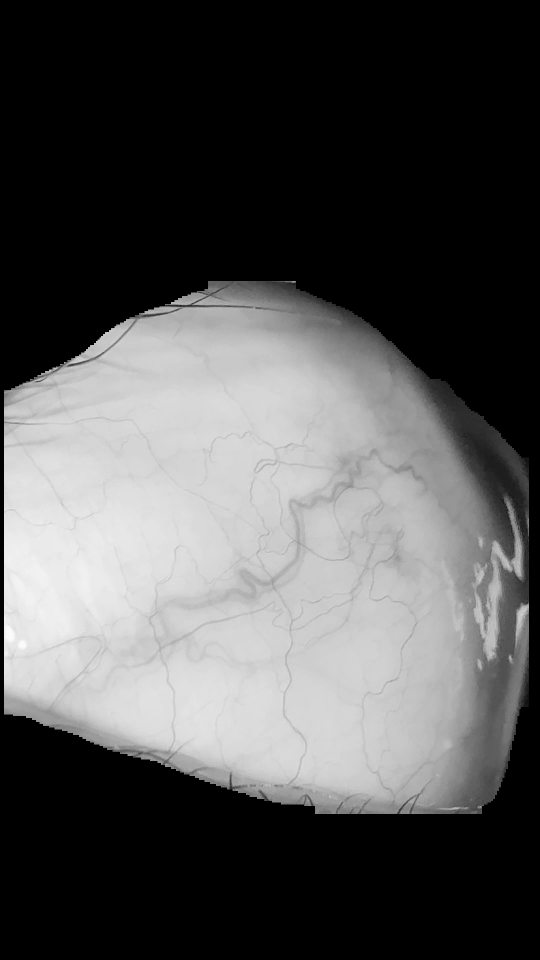

In [1]:
import cv2
import numpy as np
from PIL import Image
def show(img_rgb, scale_factor=0.25):
    # if greyscale, convert to RGB
    if len(img_rgb.shape) == 2:
        img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_GRAY2RGB)
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    scaled_img = cv2.resize(img_rgb, (img_rgb.shape[1] // int(1/scale_factor), img_rgb.shape[0] // int(1/scale_factor)))
    display(Image.fromarray(scaled_img))
    return
input_frame = r"C:\Users\dragon\Code\CatsEye-Python\output\testing_sclera\frames\frame090.png"
off_frame = r"C:\Users\dragon\Code\CatsEye-Python\output\testing_sclera\frames\frame003.png"
img_in = cv2.imread(input_frame)
img_off = cv2.imread(off_frame)
print(f"Original image shape: {img_in.shape}")
show(cv2.cvtColor(img_in, cv2.COLOR_BGR2GRAY))

In [ ]:
from CV_steps.XCorr import gen_mask
# import scikit-image as ski

# print(f"Mask shape: {img_in.shape}, unique values: {np.unique(img_in)}")

mask = gen_mask(img_in)
mask_off = gen_mask(img_off)
img_in_gray = cv2.cvtColor(img_in, cv2.COLOR_BGR2GRAY)
# show(mask)

# mask 

# edges = cv2.Canny(img_in, 50, 50)
img_blur = cv2.GaussianBlur(img_in, (3,3), 0)
img_blur2 = cv2.GaussianBlur(img_off, (3,3), 0)
canny = cv2.Canny(img_in, 20, 50, apertureSize=3, L2gradient=False)
canny2 = cv2.Canny(img_off, 20, 50, apertureSize=3, L2gradient=False)
laplacian = cv2.Laplacian(img_in, cv2.CV_64F, ksize=3)
laplacian_abs = cv2.convertScaleAbs(laplacian)
laplacian2 = cv2.Laplacian(img_off, cv2.CV_64F, ksize=3)
laplacian2_abs = cv2.convertScaleAbs(laplacian2)
sobelxy = cv2.Sobel(src=img_blur, ddepth=cv2.CV_64F, dx=1, dy=1, ksize=5) # Combined X and Y Sobel Edge Detection
sobel = cv2.convertScaleAbs(sobelxy)
sobelxy2 = cv2.Sobel(src=img_blur2, ddepth=cv2.CV_64F, dx=1, dy=1, ksize=5) # Combined X and Y Sobel Edge Detection
sobel2 = cv2.convertScaleAbs(sobelxy2)

ridge = cv2.ximgproc.RidgeDetectionFilter.create()
frangi = ridge.getRidgeFilteredImage(img_in)
frangi2 = ridge.getRidgeFilteredImage(img_off)

zhang = cv2.ximgproc.thinning(frangi, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)
otsu = cv2.threshold(frangi, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
otsu2 = cv2.threshold(frangi2, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
# otsu_2 = cv2.ximgproc.thinning(otsu)
otsu_expanded = cv2.morphologyEx(otsu, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=1)
otsu_expanded2 = cv2.morphologyEx(otsu2, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=1)
# otsu_dilated = cv2.dilate(otsu, np.ones((3,3), np.uint8), iterations=1)
# otsu_dilated2 = cv2.dilate(otsu2, np.ones((5,5), np.uint8), iterations=5)
show(otsu_expanded)
# show(zhang)
# show(canny)
# show(laplacian_abs)
# show(sobel)

In [ ]:
in1 = 
in2 = ridge2

def orbital_strike(in1, in2, orbeez=5000):
    orb = cv2.ORB_create(orbeez)    
    bf  = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    kp1, des1 = orb.detectAndCompute(in1, mask=mask)
    kp_img = cv2.drawKeypoints(in1, kp1, in1, color=(0,255,0), flags=0)
    show(kp_img)
    kp2, des2 = orb.detectAndCompute(in2, mask=mask_off)
# matches = bf.match(des1, des2)
# matches = sorted(matches, key = lambda x:x.distance)
    matcher = cv2.DescriptorMatcher.create('BruteForce')
    matches = matcher.knnMatch(des1,des2, 10)
# Filter matches using the Lowe's ratio test
    ratio_thresh = 0.7
    good_matches = []
    for i, (m,n) in enumerate(matches):
        if m.distance < ratio_thresh * n.distance:
            good_matches.append(m)
    matched = cv2.drawMatches(in1, kp1, in2, kp2, good_matches[:10], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    cv2.imwrite(r"C:\Users\dragon\Code\CatsEye-Python\output\testing_sclera\frames\feature_match.png", matched)

orbital_strike(in1, in2)

In [ ]:
# get the average color in a masked area
masked_area = img_in[mask == 255]
avg_color = np.mean(masked_area, axis=0)
print(f"Average color in masked area: {avg_color}")
average_color = np.round(avg_color).astype(np.uint8) / 2
background_elim = cv2.inRange(img_in, avg_color - 10, avg_color + 10)
# subtract the average color using cv2.subtract to avoid uint8 wraparound
avg_col = np.round(avg_color).astype(np.uint8)
bg = np.full(img_in.shape, avg_col, dtype=np.uint8)
img_bg_elim = cv2.subtract(img_in, bg)
# clahe
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_bg_elim = clahe.apply(cv2.cvtColor(img_bg_elim, cv2.COLOR_BGR2GRAY))
show(img_bg_elim)


In [2]:
def normalize_and_enhance(image_bgr, sigma_x=51, scale=128, clip_limit=10.0, tile_grid_size=(16, 16)):
    # Estimate background as a slow-varying Gaussian blur
    bg_model = cv2.GaussianBlur(image_bgr, (0, 0), sigmaX=sigma_x)

    image_float = image_bgr.astype(np.float32) + 1.0
    bg_float = bg_model.astype(np.float32) + 1.0

    image_normalized = np.clip((image_float / bg_float) * scale, 0, 255).astype(np.uint8)

    # CLAHE on LAB luminance channel
    lab_image = cv2.cvtColor(image_normalized, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab_image)
    clahe_obj = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_enhanced = clahe_obj.apply(l_channel)

    return cv2.cvtColor(cv2.merge([l_enhanced, a_channel, b_channel]), cv2.COLOR_LAB2BGR)

result = cv2.cvtColor(normalize_and_enhance(img_in), cv2.COLOR_BGR2GRAY)
result2 = cv2.cvtColor(normalize_and_enhance(img_off), cv2.COLOR_BGR2GRAY)
result = cv2.bitwise_and(result, result, mask=mask)
result2 = cv2.bitwise_and(result2, result2, mask=mask_off)
# rolling ball filter
# cv2
# result = cv2.rollingBall(result, 50)

# result = cv2.threshold(result, 200, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
# result = cv2.Canny(result, 20, 30, apertureSize=3, L2gradient=False)
show(result)
# result3 = result[mask == 255]
# result = cv2.threshold(result[mask == 255], 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
# cv2.imwrite(out_path, result3)
# display(Image.fromarray(result3))
cv2.imwrite(r"C:\Users\dragon\Code\CatsEye-Python\output\testing_sclera\frames\normalized.png", result)



NameError: name 'mask' is not defined

In [ ]:
# Normalize in float to avoid precision loss
img_float = img_in.astype(np.float32) + 1        # +1 avoids division by zero
bg_float  = avg_col.astype(np.float32) + 1

img_normalized = img_float / bg_float             # true illumination removal
img_normalized = np.clip(img_normalized * 128, 0, 255).astype(np.uint8)  # rescale to visible range

show(img_normalized)

In [ ]:
# ridge filtering
ridger = cv2.ximgproc.RidgeDetectionFilter.create()
ridge1 = ridger.getRidgeFilteredImage(result)
ridge1 = cv2.threshold(ridge1, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
ridge1 = cv2.morphologyEx(ridge1, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=1)
# kp1, des1 = orb.detectAndCompute(ridge1, mask=mask)
# ridge1 = cv2.drawKeypoints(ridge1, kp1, ridge1, color=(0,255,0), flags=0)
ridge2 = ridger.getRidgeFilteredImage(result2)
ridge2 = cv2.threshold(ridge2, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
ridge2 = cv2.morphologyEx(ridge2, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=1)

show(ridge2)



In [ ]:
# simply cross correlate and translate the 2 together and get the match score
import cv2
import numpy as np

def find_translation_template(template, source):
    """
    Finds where the 'template' best fits into the 'source' image.
    Returns the top-left (y, x) coordinates and the correlation score.
    """
    # 1. Ensure images are grayscale for standard correlation
    if len(template.shape) == 3:
        template = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)
    if len(source.shape) == 3:
        source = cv2.cvtColor(source, cv2.COLOR_BGR2GRAY)

    # 2. Apply template matching using Normalized Cross-Correlation
    # TM_CCOEFF_NORMED returns a score between -1 and 1
    res = cv2.matchTemplate(source, template, cv2.TM_CCOEFF_NORMED)

    # 3. Locate the best match
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

    # Note: max_loc is (x, y) in OpenCV, we return (y, x) for consistency
    top_left_y, top_left_x = max_loc[1], max_loc[0]
    
    return (top_left_y, top_left_x), max_val

def create_alignment_overlay(img1, img2, shift):
    """
    Overlays img1 (Red) and img2 (Green) based on a calculated (y, x) shift.
    """
    # 1. Convert inputs to grayscale if they are color
    if len(img1.shape) == 3: img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    if len(img2.shape) == 3: img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    h, w = img1.shape
    dy, dx = shift

    # 2. Create an empty RGB canvas
    # We use the size of img1 as the base
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    # Coordinates for img1 (The Reference)
    y1_start, y1_end = max(0, dy), min(h, h + dy)
    x1_start, x1_end = max(0, dx), min(w, w + dx)

    # Coordinates for img2 (The Shifted Image)
    y2_start, y2_end = max(0, -dy), min(h, h - dy)
    x2_start, x2_end = max(0, -dx), min(w, w - dx)

    # 4. Assign images to channels (Red channel is index 2, Green is index 1)
    # Note: OpenCV uses BGR, so [..., 2] is Red and [..., 1] is Green
    overlay[y1_start:y1_end, x1_start:x1_end, 2] = img1[y1_start:y1_end, x1_start:x1_end]
    overlay[y1_start:y1_end, x1_start:x1_end, 1] = img2[y2_start:y2_end, x2_start:x2_end]

    return overlay

def create_diff_map(img1, img2, shift):
    h, w = img1.shape
    dy, dx = shift
    
    # Align img2 to img1 using a transformation matrix
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    img2_aligned = cv2.warpAffine(img2, M, (w, h))
    
    # Compute absolute difference
    diff = cv2.absdiff(img1, img2_aligned)
    
    # Optional: Enhance the difference so small errors pop out
    diff_enhanced = cv2.equalizeHist(diff) 
    
    return diff_enhanced
# --- Workflow Example ---
# 1. Find the shift
# (y, x), score = find_translation_template(img_template, img_source)
# 
# 2. Visualize
# result_vis = create_alignment_overlay(img_source, img_template, (y, x))
# cv2.imshow("Alignment (Yellow = Match)", result_vis)
# cv2.waitKey(0)
# Example usage:
# (y, x), score = find_translation_template(small_patch, large_scene)
(y, x), score = find_translation_template(result, result2)
(y2, x2), score2 = find_translation_template(img_in, img_off)
overlay = create_alignment_overlay(result, result2, (y, x))
overlay2 = create_alignment_overlay(img_in, img_off, (y2, x2))
diff_map = create_diff_map(img_in, img, (y, x))
show(diff_map)
# show(result2)
# show(overlay)
# show(img_in)
# show(overlay2)
print(f"Best match shift (y={y}, x={x}) with score={score:.4f}")
print(f"Best match shift (y={y2}, x={x2}) with score={score2:.4f}")



In [4]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.registration import phase_cross_correlation
from skimage.transform import warp_polar, rotate, rescale
from skimage.util import img_as_float
import cv2

radius = 705
angle = 35
image = result
image = img_as_float(image)
rotated = rotate(image, angle)
image_polar = warp_polar(image, radius=radius, channel_axis=-1)
rotated_polar = warp_polar(rotated, radius=radius, channel_axis=-1)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
ax = axes.ravel()
ax[0].set_title("Original")
ax[0].imshow(image)
ax[1].set_title("Rotated")
ax[1].imshow(rotated)
ax[2].set_title("Polar-Transformed Original")
ax[2].imshow(image_polar)
ax[3].set_title("Polar-Transformed Rotated")
ax[3].imshow(rotated_polar)
plt.show()

shifts, error, phasediff = phase_cross_correlation(
    image_polar, rotated_polar, normalization=None
)


ModuleNotFoundError: No module named 'matplotlib'

In [5]:
!python -m pip install matplotlib

  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 0/6 [pyparsing]
   ----------------


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
